In [97]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
url="https://drive.google.com/uc?id=15B0YXLJhx41faA2rVyifWMjlmpuFqAxc"
data=pd.read_csv(url)
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [100]:
# Here as we are predicting the ability to get the loan the column loan_status is our target column
# Remaining Columns are features
# Based on the features we have to predict the target columns

In [101]:
data["Dependents"].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

Now by looking at a Dataset, we know one thing the "**Loan_ID**" column has no impact on the status of the loan so we can simply remove that column from the dataset.

In [102]:
data=data.drop("Loan_ID",axis=1)

In [103]:
# For including all the columns in describe 
# as the data type of the column like dependents is object we use
data.describe(include=["object"])

C:\Users\manis\AppData\Local\Temp\ipykernel_32748\1018107564.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=["object"])


,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,601,611,599,614,582,614,614
unique,2,2,4,2,2,3,2
top,Male,Yes,0,Graduate,No,Semiurban,Y
freq,489,398,345,480,500,233,422


In [104]:
data.isna().sum()
# For checking the null values

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [105]:
cat_cols = data.select_dtypes(include=['object','string']).columns.tolist()

num_cols = data.select_dtypes(include='number').columns.tolist()
print(cat_cols,num_cols)

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status'] ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


## Skewness of the dataset

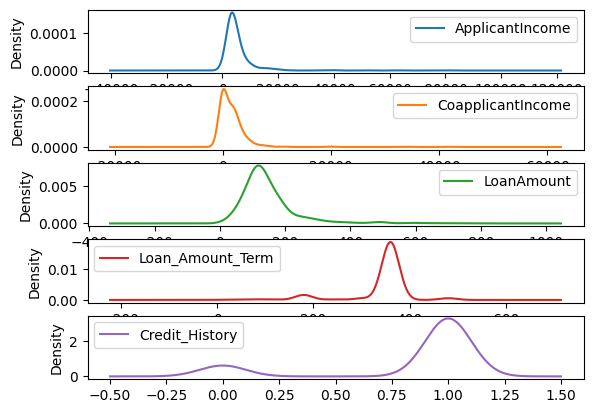

In [106]:
import matplotlib.pyplot as plt
data.plot(kind="density",subplots=True,sharex=False)
plt.show()

#### <font color='red'>**Motivation:**</font>

<font color='blue'>**Imagine you're working as a data analyst for a financial institution, and your company processes loan applications.**</font>

- You want to gain insights into the distribution of applicant incomes and its potential impact on the loan approval process.
- To do this, you focus on a specific feature: **"ApplicantIncome."**

Now, the significance of understanding skewness in "ApplicantIncome" becomes apparent.
- Skewness helps uncover patterns in the distribution of income, crucial for assessing the financial profiles of loan applicants.

This is where **skewness** comes into play.

Skewness is valuable for several reasons in the analysis of loan data:

1. **Understanding Income Distribution:**
   - Skewness provides insights into whether there are a few individuals with exceptionally high or low incomes, shaping the distribution of applicant incomes.

2. **Impact on Loan Approval:**
   - The skewed nature of income distribution may influence the loan approval process, as lenders need to be aware of extremes in income levels.

3. **Identifying Outliers:**
   - Skewness helps identify potential outliers in income data, ensuring they are appropriately handled for accurate analyses.

This understanding informs decision-making in lending practices, ensuring thorough assessments of applicant financial profiles.

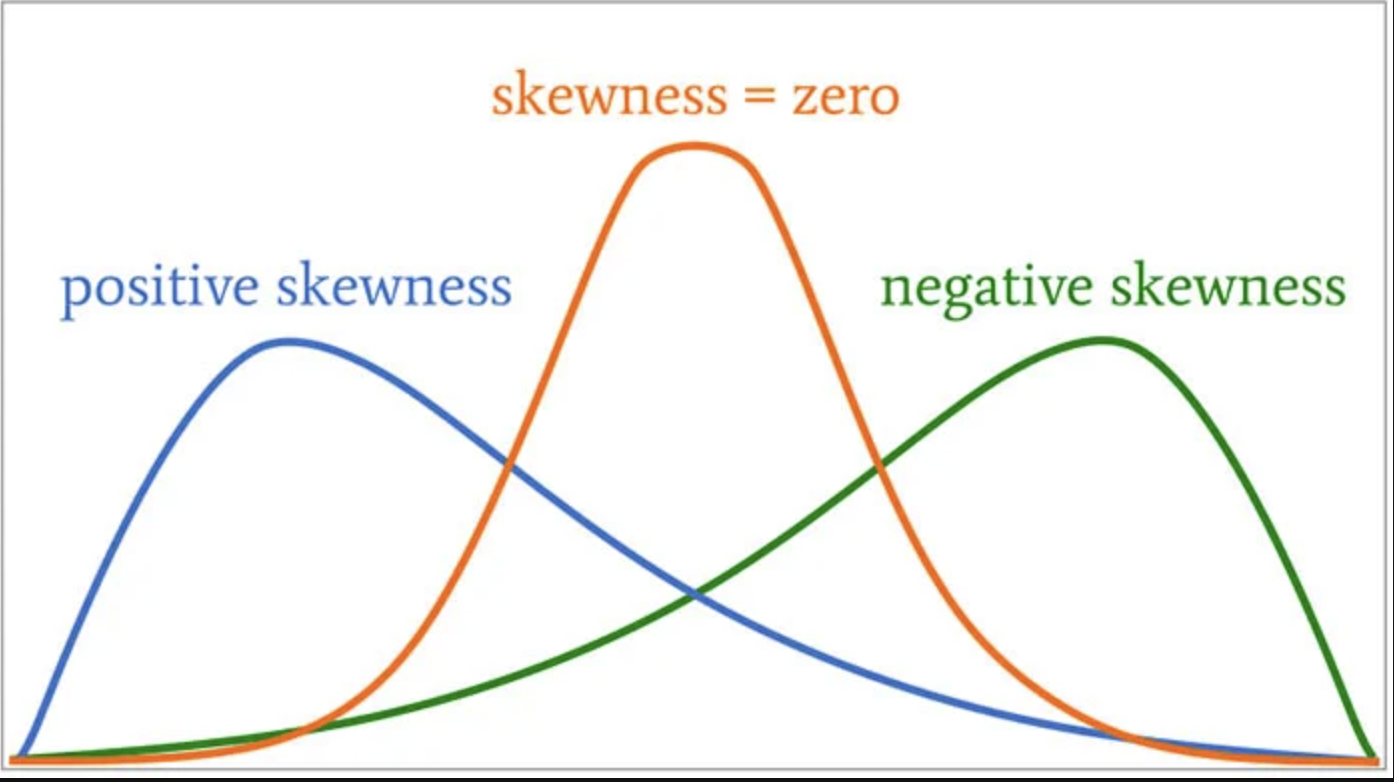

<font color='violet'>**What is Skewness**:</font>

- <font color='orange'>**Symmetrical Data (No Skewness)**:</font> If a distribution is perfectly balanced, with data evenly spread on both sides of the center, it's like a hill with equal slopes on both sides. We call this "symmetrical" or "no skewness."

- <font color='orange'>**Positive Skew (Right Skew)**:</font> When most of the data is on the left side (lower values) and a long tail extends to the right (higher values), it's like a hill that's steeper on the left and has a long, gentle slope on the right.

- <font color='orange'>**Negative Skew (Left Skew)**:</font> When most of the data is on the right side (higher values) and a long tail extends to the left (lower values), it's like a hill that's steeper on the right and has a long, gentle slope on the left.

<font color='violet'>**Why Skewness Matters**:</font>

Skewness is important because it helps us understand the data we're dealing with. It can tell us about things like:

- Where the "typical" or "average" value is.
- Whether there are extreme values far from the average.
- Whether the data tends to be more on one side or the other.

In [107]:
display(data.skew(numeric_only=True))

ApplicantIncome      6.539513
CoapplicantIncome    7.491531
LoanAmount           2.677552
Loan_Amount_Term    -2.362414
Credit_History      -1.882361
dtype: float64

1. **Applicant Income and Coapplicant Income:**
   -  Positive skewness indicates lower incomes for many applicants and co-applicants, with a few having exceptionally high incomes.

2. **Loan Amount:**
   -  Loan amount also has positive skewness. Most loans are smaller, but there are a few that are much larger.

3. **Loan Amount Term:**
   - This feature has negative skewness. It indicates that most loan terms are longer (possibly a standard term), but there might be a few shorter-term loans.

4. **Credit History:**
   - Credit history has negative skewness, suggesting that most applicants have a positive credit history (1), but there might be a few with a negative credit history (0).

<br>

<font color='violet'>Now, why does this matter for Exploratory Data Analysis?</font>

- It provides insights into data distributions, indicating whether values are concentrated around the average or if there are extremes.
- Skewness aids in identifying patterns within features, guiding decision-making processes.
- EDA involving skewness informs data preprocessing steps, such as applying transformations to improve distribution suitability for analysis.
- Knowing the concentration of values helps in making informed decisions, such as influencing lending strategies based on income distribution.

> <font color='violet'>**Why it only returns numerical columns:**</font>

1. **Numerical vs. Categorical:**

- Skewness is a statistical measure applicable to numerical data.  
- Categorical data represents categories or labels, and skewness is not meaningful for such data.  


2. **Interpretability:**

- Skewness is meaningful for continuous or interval data, where "more" or "less" can be measured.
- Categorical variables, represented by labels rather than measurable quantities, do not provide meaningful skewness information.
  

<font color='violet'>Skewness and the Mean, Median and Mode</font>

As we know for **Symmetrical data** (No skewness),
- The mean, median and mode of the data coincide at the same point (the centre of distribution).
- This is because the tails on both sides are mirror images of each other. Hence, there is balance.

<br>

> **Do you think these points will conincide for skewed distribution as well?**

No. Let's consider both cases one by one.

<br>

> **Positive/Right Skewed Distribution**

- Mode aligns with the peak, situated to the right due to a longer right tail.
- The distribution stretches rightward, making the mean typically greater than the median.
- Mean is sensitive to outliers in the tail, while the median is less affected, providing a more robust measure.

<br>

Similarly, for

> **Negatively/Left Skewed Distribution**

Here,
- Mode aligns with the peak, positioned to the left due to a longer left tail.
- The distribution stretches leftward, causing the mean to be typically less than the median.

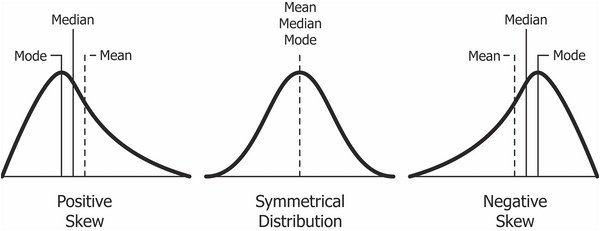

# 📊 Kurtosis — The Ultimate Intuition Guide

> **Kurtosis measures how likely a dataset is to contain extreme values (outliers).**
>
> 🎯 Think of Kurtosis as a measure of **tail heaviness**, not just peak height.

---

# 🧠 The One-Line Definition

```text
Skewness  → Direction of the Tail

Kurtosis  → Thickness of the Tail
```

---

# 🎯 Why Do We Need Kurtosis?

Imagine you're analyzing:

* 💰 Loan Amounts
* 📈 Stock Market Returns
* 🛒 Customer Spending
* 🚗 Insurance Claims

Two datasets may have:

✅ Same Mean
✅ Same Median
✅ Same Standard Deviation

But one dataset may contain **many extreme values** while the other doesn't.

Kurtosis helps identify this hidden risk.

---

# 📦 Understanding Tails

### Normal Distribution

```text
                █
             ███████
          █████████████
             ███████
                █
```

```text
Normal Tails
Normal Outliers
```

---

### Heavy Tails

```text
█                            █
██                          ██
██████████████████████████████
██                          ██
█                            █
```

```text
Many Extreme Values
More Outliers
Higher Risk
```

---

# 🚗 Real-Life Example

### Vehicle Loan Amounts

```text
₹2L
₹3L
₹4L
₹5L
₹6L
₹50L
```

Most loans:

```text
₹2L – ₹6L
```

But one loan:

```text
₹50L
```

creates an extreme value.

This increases:

```text
Kurtosis ↑
```

---

# 🔥 Types of Kurtosis

---

## 1️⃣ Leptokurtic (High Kurtosis)

### Excess Kurtosis > 0

```text
            █
           ███
         ███████
       ███████████
          ███
           █
```

### Characteristics

✅ Heavy Tails

✅ More Outliers

✅ Higher Risk

✅ Extreme Events Occur More Frequently

---

### Example

```text
10
11
12
13
14
15
200
```

```text
Most values are normal

One value is extremely large
```

---

### Interpretation

```text
⚠️ High Risk Dataset

⚠️ Outliers Exist

⚠️ Unexpected Events Possible
```

---

## 2️⃣ Mesokurtic (Normal Kurtosis)

### Excess Kurtosis = 0

```text
                █
             ███████
          █████████████
             ███████
                █
```

### Characteristics

✅ Similar to Normal Distribution

✅ Moderate Tails

✅ Average Number of Outliers

---

### Example

```text
45
48
50
51
52
49
50
```

---

### Interpretation

```text
Normal Behavior

No Major Extremes
```

---

## 3️⃣ Platykurtic (Low Kurtosis)

### Excess Kurtosis < 0

```text
      ███████████████
   ████████████████████
 ███████████████████████
   ████████████████████
      ███████████████
```

### Characteristics

✅ Light Tails

✅ Fewer Outliers

✅ More Evenly Spread Data

---

### Example

```text
10
20
30
40
50
60
70
```

---

### Interpretation

```text
Very Stable Dataset

Few Extreme Values
```

---

# 🧮 Excess Kurtosis

Normal Distribution has:

```text
Kurtosis = 3
```

To simplify interpretation:

```text
Excess Kurtosis = Kurtosis − 3
```

---

## Quick Interpretation

| Excess Kurtosis | Meaning                      |
| --------------- | ---------------------------- |
| > 0             | Heavy Tails / More Outliers  |
| = 0             | Normal Distribution          |
| < 0             | Light Tails / Fewer Outliers |

---

# 📊 Loan Dataset Interpretation

---

## Applicant Income

### Very High Kurtosis

```text
Most applicants earn average income

Few applicants earn extremely high income
```

Example:

```text
₹20,000
₹25,000
₹30,000
₹35,000
₹5,00,000
```

### Meaning

```text
Heavy Tail

Income Outliers Present
```

---

## Coapplicant Income

```text
Most Coapplicants
      ↓
Normal Income

Few Coapplicants
      ↓
Very High Income
```

### Meaning

```text
Positive Kurtosis
```

---

## Loan Amount

```text
Most Loans
      ↓
Moderate

Few Loans
      ↓
Extremely Large
```

### Meaning

```text
Heavy Right Tail
```

---

## Total Income

```text
Most Families
      ↓
Average Income

Few Families
      ↓
Extremely High Income
```

### Meaning

```text
Positive Kurtosis
```

---

## Credit History

```text
Most Applicants
      ↓
Similar Scores

Few Applicants
      ↓
Very Different Scores
```

### Meaning

```text
Unusual Cases Exist
```

---

## EMI / Loan Amount Per Year

### Extremely High Kurtosis

```text
Most EMI Values
      ↓
Normal

Few EMI Values
      ↓
Extremely High
```

### Meaning

```text
⚠️ Strong Outliers

⚠️ Heavy Tails

⚠️ Higher Financial Risk
```

---

# 🔄 Skewness vs Kurtosis

| Metric   | Measures          |
| -------- | ----------------- |
| Skewness | Direction of Tail |
| Kurtosis | Thickness of Tail |

---

### Skewness

```text
Left Tail
      ↓
Negative Skew

Right Tail
      ↓
Positive Skew
```

---

### Kurtosis

```text
Thin Tail
      ↓
Low Kurtosis

Heavy Tail
      ↓
High Kurtosis
```

---

# 🎯 Financial Risk Perspective

### High Kurtosis Means

```text
Rare Events
Occur More Often
Than Expected
```

Examples:

* 💸 Loan Defaults
* 📉 Stock Market Crashes
* 🛒 Abnormally Large Purchases
* 🚨 Fraudulent Transactions

---

# 🚀 Interview Cheat Sheet

## Skewness

```text
Which Direction Is The Tail?
```

---

## Kurtosis

```text
How Heavy Is The Tail?
```

---

## Excess Kurtosis

```text
> 0  → More Outliers

= 0  → Normal

< 0  → Fewer Outliers
```

---

# ⭐ Golden Rule

> **Kurtosis tells us how prone a dataset is to extreme values and outliers compared to a normal distribution.**

```text
Higher Kurtosis
        ↓
More Extreme Values
        ↓
Higher Risk
```

```text
Lower Kurtosis
        ↓
Fewer Extreme Values
        ↓
More Stability
```


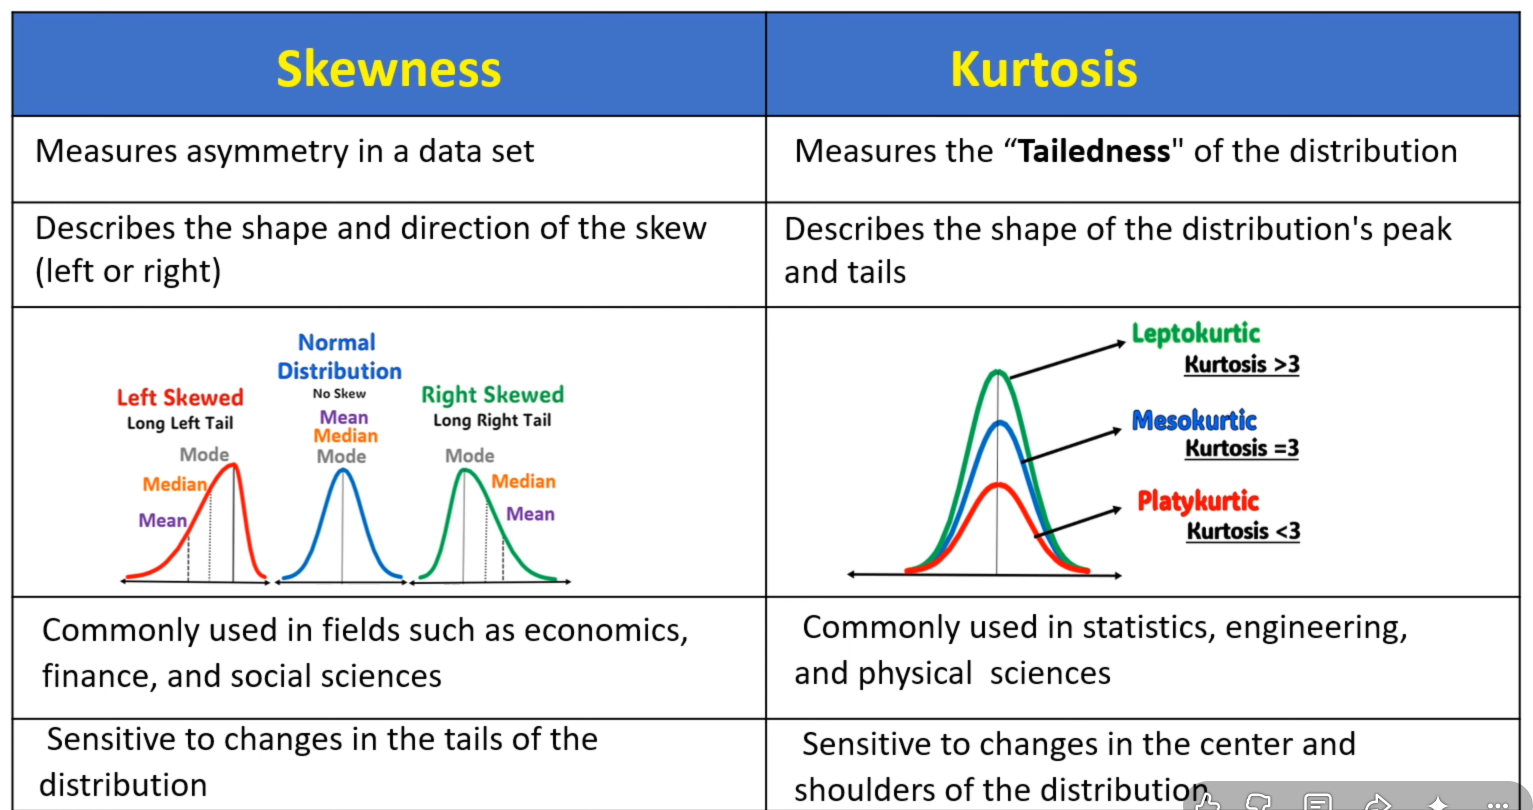

In [108]:
data.kurt(numeric_only=True)

ApplicantIncome      60.540676
CoapplicantIncome    84.956384
LoanAmount           10.401533
Loan_Amount_Term      6.673474
Credit_History        1.548763
dtype: float64

Here's a simpler way to understand the above kurtosis values:

1. **Applicant and Coapplicant:** Very high positive kurtosis means these distributions have heavy tails with some extreme values—indicating a few individuals with much higher incomes than the rest.
  

2. **Loan Amount and Total Income:** Positive kurtosis suggests heavy tails with some significantly higher values than the center.  



3. **Loan Amount Term and Able to Pay EMI:** Positive kurtosis implies a concentration of data around the mean but with some values noticeably different.
  

4. **Credit History:** Positive kurtosis suggests a distribution with heavy tails, indicating a few applicants with a very different credit history.
  

5. **Loan Amount per Year and EMI:** Extremely high positive kurtosis means their distributions have extremely heavy tails with values much higher than the center.

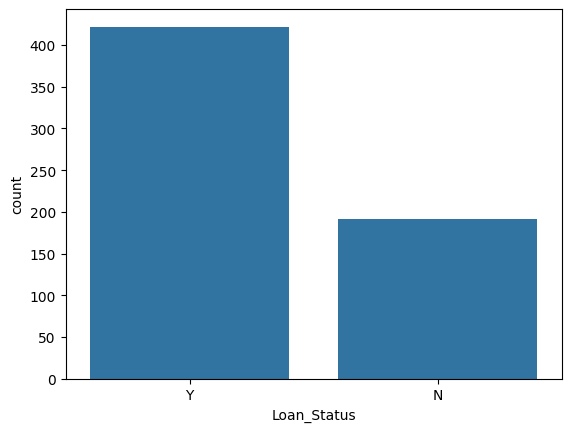

In [109]:
# Univariate analysis for loan status
sns.countplot(data=data,x="Loan_Status")
plt.show()

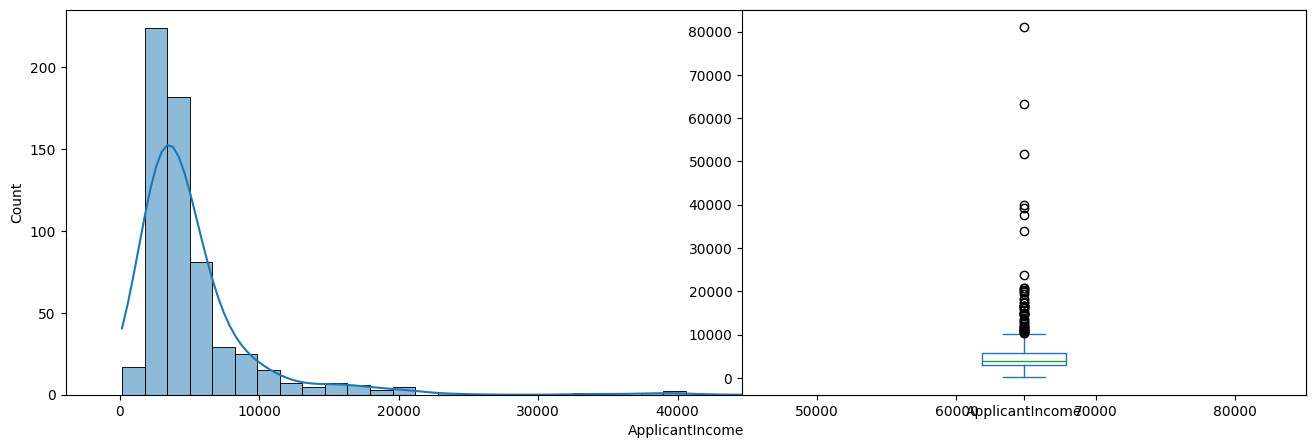

In [110]:
sns.histplot(data["ApplicantIncome"], kde=True)

plt.subplot(122)
data["ApplicantIncome"].plot.box(figsize=(16,5))
plt.show()

In [111]:
# In the first graph the graph is right skewed and the kde is also high in the middle which
# Signifies that some people are earning way more than others and in the box plot 
# reveals that there are more outliers in data

Let's calculate the mean of "ApplicantIncome" and group it by the "Loan_Status" column.

In [112]:
display(data.groupby(by="Loan_Status")["ApplicantIncome"].mean())

Loan_Status
N    5446.078125
Y    5384.068720
Name: ApplicantIncome, dtype: float64

In [113]:
from scipy.stats import ttest_ind

a = data[data["Loan_Status"]=="Y"]["ApplicantIncome"]
b = data[data["Loan_Status"]=="N"]["ApplicantIncome"]

# H0: Income has NO effect on loan approval.
# Ha: Dependent on income

ttest_ind(a, b)
# As the p value is much greater it is suggesting failed to reject null hypothesis
# The probability of occuring this is very huge


TtestResult(statistic=np.float64(-0.11650844828724542), pvalue=np.float64(0.907287812130518), df=np.float64(612.0))

## <font color='sky blue'>**Binning** </font>

<font color='orange'>Binning is like sorting and organizing information into groups. We do this to make it easier to understand and analyze.</font>

Let's take "**ApplicantIncome**" as an example.

<font color='orange'>Why do we need binning for EDA?</font>

- Binning involves organizing data into groups, which helps simplify complex information, like a wide range of income values.
- By grouping incomes into categories or bins, we can identify patterns and trends more easily.
  - For example, we can see how many people fall into different income ranges, making the data more interpretable, especially for non-specialists.
  - Bins also facilitate comparisons between groups, allowing us to analyze low, medium, and high-income categories without focusing on individual numbers.

In [114]:
bins=[0,2500,4000,6000, 8000, 10000, 20000, 40000, 81000]
group=['Low', 'Average', 'Medium', 'H1', 'H2', 'H3', 'H4', 'Very High']
display(len(bins),len(group))

9

8

In [115]:
data["Income_Bin"]=pd.cut(data["ApplicantIncome"],bins,labels=group)
display(data.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_Bin
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,Medium
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,Medium
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,Average
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,Average
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,Medium


In [116]:
pd.crosstab(data["Income_Bin"],data["Loan_Status"])
# pd.crosstab(data["Gender"],data["Loan_Status"],values=data["ApplicantIncome"],aggfunc="mean")
# this means the staus of those which is not approved and the mean income is given



Loan_Status,N,Y
Income_Bin,,
Low,34,74
Average,67,159
Medium,45,98
H1,20,34
H2,9,22
H3,13,27
H4,3,6
Very High,1,2


In [117]:
# Example Problem
import pandas as pd

df = pd.DataFrame({
    "Brand": ["Toyota","Toyota","Honda","Honda","Toyota","Honda"],
    "Fuel": ["Petrol","Diesel","Petrol","Diesel","Petrol","Diesel"],
    "Price": [10,12,9,11,14,13]
})
pd.crosstab(df["Brand"],df["Fuel"],values=df["Price"],aggfunc="mean")

Fuel,Diesel,Petrol
Brand,,
Honda,12.0,9.0
Toyota,12.0,12.0


Loan_Status,N,Y
Income_Bin,,
Low,0.314815,0.685185
Average,0.296460,0.703540
Medium,0.314685,0.685315
H1,0.370370,0.629630
H2,0.290323,0.709677
H3,0.325000,0.675000
H4,0.333333,0.666667
Very High,0.333333,0.666667


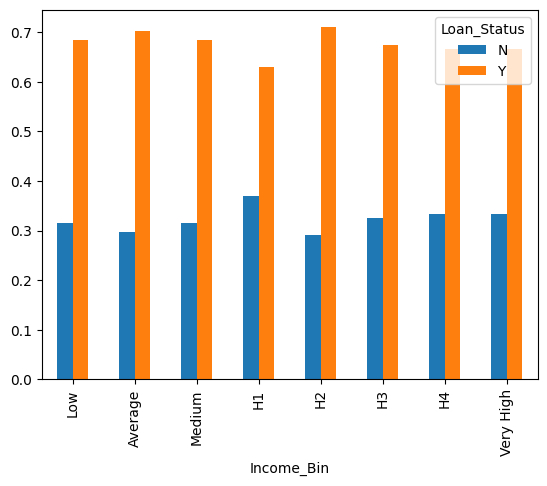

In [118]:
Income_bin = pd.crosstab(data["Income_Bin"],data["Loan_Status"], normalize="index")
# Here normalize index means it divides the final value with sum of every rows
display(Income_bin)
Income_bin.plot(kind="bar")
plt.show()

In [119]:
# We will perform a chi_squared test to check the association between two categorical vaiables
from scipy.stats import chi2_contingency
Income_bin = pd.crosstab(data["Income_Bin"],data["Loan_Status"]).values
pvalue=chi2_contingency(Income_bin)
display(pvalue)
# our h0 was there is no relationship between the two variables because of we failed 
# to rject this because of high p value




Chi2ContingencyResult(statistic=np.float64(1.2420001711303135), pvalue=np.float64(0.9899274842922701), dof=7, expected_freq=array([[ 33.77198697,  74.22801303],
       [ 70.67100977, 155.32899023],
       [ 44.71661238,  98.28338762],
       [ 16.88599349,  37.11400651],
       [  9.69381107,  21.30618893],
       [ 12.50814332,  27.49185668],
       [  2.81433225,   6.18566775],
       [  0.93811075,   2.06188925]]))

## <font color='orange'>**Creating new features**</font>

Creating new features, like converting "Loan_Amount_Term" to years, simplifies complex information, making it easier to understand.

In this example, converting the loan term into years helps in assessing the duration more intuitively, assisting both borrowers and lenders in their decision-making process.

##### <font color='sky blue'>**Loan Amount Term**</font>


Consider two loan applicants:
- Person 1 earns 20L and applies for a 50L loan.
- Person 2 earns 30L and applies for a 5CR loan.

Which is more likely to get a loan? Person 1, right?

Now, considering only salary and loan status can explain this counterintuitive scenario. Hence, "Loan_amount" is crucial:
- It directly impacts loan approval chances, with lenders evaluating it against the applicant's income to assess risk and repayment capacity.
- This aids strategic decision-making, offering a holistic view of financial profiles and influencing tailored loan offers.

Regarding "Loan_Amount_Term":
- It's essential as it indicates the loan repayment duration.
- This affects monthly payments (EMIs), affordability, and risk for both parties.
- It also impacts interest payments, reflects market conditions, and ensures regulatory compliance.
- Understanding this term is vital for informed loan decisions and financial planning.

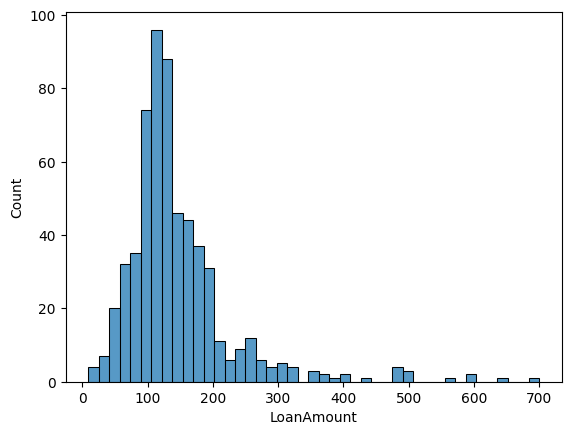

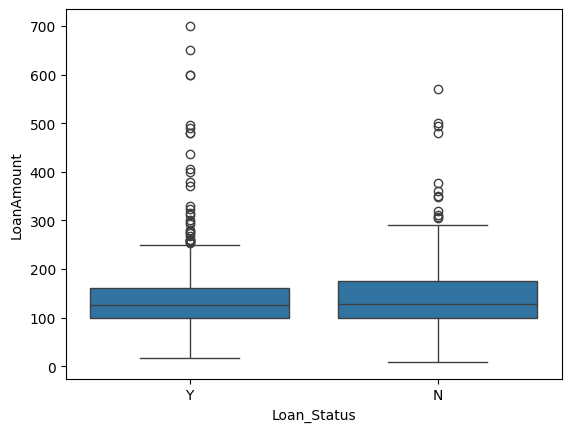

In [120]:
sns.histplot(data['LoanAmount']);
plt.show()
sns.boxplot(data=data,y="LoanAmount",x="Loan_Status")
plt.show()

In [121]:
# From the first graph it is clear that the loan amount is completley right skewed meaning that pretty
# Much loans are small amount not with hugge amount
# And in second graph in the yes section high loans are also accepted indicating the presence of outliers


## Feature Engineering 2

In [122]:
updatedurl="https://drive.google.com/uc?id=1JR9TDe1BQN9crA5n6JrL_clnNY1AhebJ"
updata=pd.read_csv(updatedurl)
updata.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,TotalIncome,TotalIncome_bin,Loan_Amount_per_year,EMI,Able_to_pay_EMI
0,Male,No,0,Graduate,No,5849,0.0,NaN,30.0,1.0,Urban,Y,Medium,5849.0,High,NaN,NaN,0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30.0,1.0,Rural,N,Medium,6091.0,High,4.266667,355.555556,1
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,30.0,1.0,Urban,Y,Average,3000.0,Low,2.200000,183.333333,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,30.0,1.0,Urban,Y,Average,4941.0,Average,4.000000,333.333333,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,30.0,1.0,Urban,Y,Medium,6000.0,High,4.700000,391.666667,1


In [123]:
updata["Dependents"].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [124]:
# We will replace the replace the "3+" to 3
updata["Dependents"] = updata["Dependents"].replace("3+", 3)
updata["Dependents"].value_counts()

Dependents
0    345
1    102
2    101
3     51
Name: count, dtype: int64

In [125]:
pd.crosstab(updata["Credit_History"],updata["Loan_Status"])

Loan_Status,N,Y
Credit_History,,
0.0,82,7
1.0,97,378


## <font color='sky blue'>**Missing Values**</font>

In [126]:
# To find the percentage of null values in each column
updata.isna().sum()/len(updata)*100

Gender                  2.117264
Married                 0.488599
Dependents              2.442997
Education               0.000000
Self_Employed           5.211726
ApplicantIncome         0.000000
CoapplicantIncome       0.000000
LoanAmount              3.583062
Loan_Amount_Term        2.280130
Credit_History          8.143322
Property_Area           0.000000
Loan_Status             0.000000
Income_bin              0.000000
TotalIncome             0.000000
TotalIncome_bin         0.000000
Loan_Amount_per_year    5.863192
EMI                     5.863192
Able_to_pay_EMI         0.000000
dtype: float64

<font color='violet'>How To Handle Missing values?</font>

- When dealing with missing values, we categorize variables as either numerical or categorical.
- For **numerical variables**, common imputation techniques include using the mean, median, mode, or a constant value.
- For **categorical variables**, we typically use the mode to fill in missing values.

<font color='violet'>What techniques do we use to find missing values:</font>


- To identify missing values, we use functions like `isna()` or `isnull()`.
- For filling missing values, we use `fillna()`.
- To remove rows or columns with missing values, we use `dropna()`.

Now, there is one advanced technique the <font color='orange'>**Simple Imputer**</font>, which is part of a powerful library called "Scikit-learn".
  - This library supports various algorithms and pre-processing tasks like Feature Engineering.

In [127]:
# Replacing the missing values
from scipy.stats import chi2_contingency
val=pd.crosstab(updata["Credit_History"],updata["Loan_Status"])
chi2_contingency(val)
# here as p value is very low the two variables are very closely associated
updata["Credit_History"]=updata["Credit_History"].fillna(2)
updata["Credit_History"].value_counts()


Credit_History
1.0    475
0.0     89
2.0     50
Name: count, dtype: int64

<Axes: xlabel='Self_Employed', ylabel='count'>

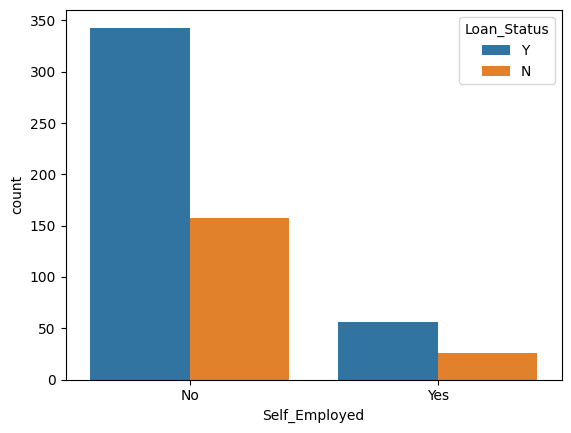

In [128]:
from scipy.stats import chi2_contingency
val=pd.crosstab(updata["Self_Employed"],updata["Loan_Status"])
chi2_contingency(val)
# As the p value is very large there is no dependence of variables 
sns.countplot(data=updata,x="Self_Employed",hue="Loan_Status")

#### <font color='violet'>Simple Imputer  </font>

In [129]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [130]:
from sklearn.impute import SimpleImputer
num_missing = ['EMI', 'Loan_Amount_per_year',  'LoanAmount',  'Loan_Amount_Term']
median_imputer=SimpleImputer(strategy="median")
mode_imputer=SimpleImputer(strategy="most_frequent")
for col in num_missing:
    updata[col]=pd.DataFrame(median_imputer.fit_transform(pd.DataFrame(updata[col])))

cat_missing = ['Gender', 'Married','Dependents']
for col in cat_missing:
    updata[col]=pd.DataFrame(mode_imputer.fit_transform(pd.DataFrame(updata[col])))
updata[cat_missing].isna().sum()    


Gender        0
Married       0
Dependents    0
dtype: int64

In [131]:
# For the age the data can be skewed or can contain outliers so we use median to eliminate the outliers and all


---
## <font color='sky blue'>**Outlier Treatment**  </font>

In [132]:
df_num=updata.select_dtypes(np.number)
df_num.drop(['Credit_History','Able_to_pay_EMI'],axis=1,inplace=True)
df_num.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,TotalIncome,Loan_Amount_per_year,EMI
0,5849,0.0,128.0,30.0,5849.0,4.383333,365.277778
1,4583,1508.0,128.0,30.0,6091.0,4.266667,355.555556
2,3000,0.0,66.0,30.0,3000.0,2.200000,183.333333
3,2583,2358.0,120.0,30.0,4941.0,4.000000,333.333333
4,6000,0.0,141.0,30.0,6000.0,4.700000,391.666667


In [133]:
# IQR Method
q1=df_num.quantile(0.25)
q3=df_num.quantile(0.75)
iqr=q3-q1
display(iqr)


ApplicantIncome         2917.500000
CoapplicantIncome       2297.250000
LoanAmount                64.500000
Loan_Amount_Term           0.000000
TotalIncome             3355.750000
Loan_Amount_per_year       2.500000
EMI                      208.333333
dtype: float64

In [134]:
# To remove outliers
df_iqr=updata[~((df_num<q1-1.5*iqr)|(df_num>q3+1.5*iqr)).any(axis=1)]
df_iqr.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,TotalIncome,TotalIncome_bin,Loan_Amount_per_year,EMI,Able_to_pay_EMI
0,Male,No,0,Graduate,No,5849,0.0,128.0,30.0,1.0,Urban,Y,Medium,5849.0,High,4.383333,365.277778,0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30.0,1.0,Rural,N,Medium,6091.0,High,4.266667,355.555556,1
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,30.0,1.0,Urban,Y,Average,3000.0,Low,2.200000,183.333333,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,30.0,1.0,Urban,Y,Average,4941.0,Average,4.000000,333.333333,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,30.0,1.0,Urban,Y,Medium,6000.0,High,4.700000,391.666667,1


### Removing outliers using the Z-score method

In [135]:
from scipy.stats import zscore
z_score_loanamount=zscore(updata["LoanAmount"])
display(z_score_loanamount)


array([-2.11241249e-01, -2.11241249e-01, -9.48996468e-01, -3.06435471e-01,
       -5.65506391e-02,  1.44275835e+00, -6.03917414e-01,  1.45737082e-01,
        2.64729859e-01,  2.41849913e+00, -9.01399357e-01, -4.37327526e-01,
        6.45506746e-01, -3.77831138e-01, -1.53206108e+00, -2.46939083e-01,
       -5.44421026e-01, -8.30003691e-01, -1.51744861e-01, -3.65931860e-01,
       -4.96823915e-01,  2.01392368e+00, -3.54032582e-01, -4.01629693e-01,
        6.24421381e-02,  5.38413247e-01, -2.82636916e-01, -4.25428248e-01,
       -1.31787408e+00, -3.06435471e-01,  6.57406024e-01, -8.53802246e-01,
       -4.73025359e-01, -3.77831138e-01,  2.07342007e+00, -2.11241249e-01,
       -5.44421026e-01, -2.08528059e-02,  4.55118303e-01, -4.25428248e-01,
       -7.82406580e-01, -1.17508274e+00, -8.41902969e-01, -1.39845583e-01,
       -5.92018136e-01, -6.87212358e-01, -1.21078058e+00, -2.08528059e-02,
       -3.06435471e-01, -2.08528059e-02, -5.44421026e-01, -3.06435471e-01,
       -4.01629693e-01, -

In [136]:
# Here the outliers where z_score >3
row_index_outliers=np.where(z_score_loanamount>3)
display(row_index_outliers)
# Similary the indexes whose z score <3 are not considered as outliers

(array([130, 155, 171, 177, 278, 308, 333, 369, 432, 487, 506, 523, 525,
        561, 604]),)

In [137]:
df_zscore=updata["LoanAmount"][~((z_score_loanamount <-3)|(z_score_loanamount >3))]
display(df_zscore.head())

0    128.0
1    128.0
2     66.0
3    120.0
4    141.0
Name: LoanAmount, dtype: float64


- `(z_scores_LoanAmount < -3) | (z_scores_LoanAmount > 3)` identifies Z-scores that are below -3 or above 3, indicating potential outliers.  
  - We are using `~` to negate this condition as we only want those rows with z scores within this range.  

- Then we are creating a new Series `(df_LoanAmount_zscore)` containing values from the `LoanAmount` column having z scores within this range

---

<font color='violet'>How to decide which method to use for outlier treatment?</font>

Consider the nature of your data and your analysis goals.

- The **Z-Score method** is ideal when your data approximates a **normal distribution** and is symmetric.
  - It quantifies data points in terms of standard deviations from the mean, making it effective for large datasets.

- On the other hand, the **IQR (Interquartile Range) method** is best when your data **doesn't follow a normal distribution or is skewed**.
  - It defines a central range based on percentiles and is less sensitive to outliers, making it a robust choice, particularly for smaller datasets.

## Q-Q Plots for Outlier Detection
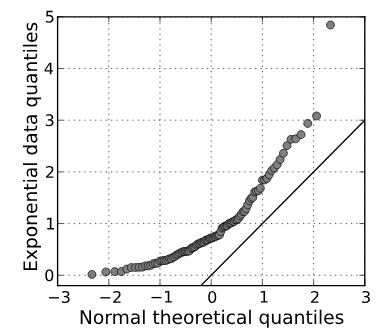

# 📈 Q-Q Plot (Quantile–Quantile Plot) Master Guide

> **Q-Q Plot = Distribution Detective 🕵️**
>
> It helps us answer one simple question:
>
> **"Does my data follow a specific distribution (usually Normal Distribution)?"**

---

# 🎯 What Does a Q-Q Plot Compare?

```text
Sample Quantiles
        VS
Theoretical Quantiles
```

Most commonly:

```text
Your Data
    VS
Normal Distribution
```

---

# 🧠 Core Intuition

Imagine lining up:

* Your data values
* Expected values from a perfect Normal Distribution

and comparing them point-by-point.

If they match:

```text
•
  •
    •
      •
        •
```

you get a **straight line**.

---

# ✅ Perfect Normal Distribution

```text
y
↑

        •
      •
    •
  •
•
─────────────────→ x
```

### Interpretation

✔ Points lie close to a straight line

✔ Data is approximately Normal

✔ Mean and spread are similar to Normal Distribution

---

# 🔥 Golden Rule

```text
Straight Line
      ↓
Data ≈ Theoretical Distribution
```

---

# 📉 Right-Skewed Distribution

Examples:

* Income
* House Prices
* Loan Amount

Most values are small, but a few are extremely large.

### Q-Q Plot Shape

```text
          •
        •
      •
    •
  •
•
       ↗
```

### Interpretation

```text
Upper Tail Curves Up
```

✅ Right Skew

✅ Large Positive Outliers

---

# 📉 Left-Skewed Distribution

Examples:

* Very easy exam scores
* Satisfaction ratings near maximum

### Q-Q Plot Shape

```text
•
  •
    •
      •
        •
          •
            ↘
```

### Interpretation

```text
Lower Tail Curves Down
```

✅ Left Skew

---

# 🎯 Heavy Tails (High Kurtosis)

Example:

```text
10
11
12
13
1000
```

### Q-Q Plot

```text
        •
      •
    •
  •
•
          •
                •
```

### Interpretation

```text
Extreme Ends Move Away
From The Line
```

✅ High Kurtosis

✅ More Outliers

✅ Heavy Tails

---

# 🎯 Light Tails (Low Kurtosis)

Data has fewer extreme values than Normal.

### Q-Q Plot

```text
       •
     •
   •
 •
•
 •
   •
```

### Interpretation

```text
Points Curve Inward
```

✅ Low Kurtosis

✅ Few Outliers

---

# 🌊 S-Shaped Pattern

### Q-Q Plot

```text
      •
    •
  •
•
  •
    •
      •
```

### Interpretation

```text
Different Kurtosis
Than Normal Distribution
```

Usually indicates:

* Heavy tails
* Light tails
* Non-normal behavior

---

# 📊 Visual Interpretation Cheat Sheet

| Pattern               | Meaning             |
| --------------------- | ------------------- |
| Straight Line         | Normal Distribution |
| Upper End Curves Up   | Right Skew          |
| Lower End Curves Down | Left Skew           |
| Ends Far Away         | Outliers            |
| S-Shape               | Different Kurtosis  |
| Strong Curvature      | Non-Normal Data     |

---

# 🏦 Loan Dataset Example

Consider:

```python
ApplicantIncome
```

Typical values:

```text
2500
3000
4000
5000
```

A few extreme values:

```text
50000
80000
100000
```

### Histogram

```text
█████████████▌
██████
███
█
```

### Q-Q Plot

```text
          •
        •
      •
    •
  •
•
           ↗↗↗
```

### Conclusion

```text
ApplicantIncome
is NOT Normally Distributed
```

Reason:

```text
Strong Right Skew
```

---

# 🧪 Why Data Scientists Love Q-Q Plots

Many statistical tests assume:

```text
Data ~ Normal Distribution
```

Examples:

* T-Test
* ANOVA
* Linear Regression Residuals

Before applying them:

```text
Histogram
      +
Q-Q Plot
```

is the standard diagnostic.

---

# 🐍 Python Example

```python
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(data, dist="norm", plot=plt)

plt.show()
```

---

# 📈 Histogram vs Q-Q Plot

| Histogram             | Q-Q Plot            |
| --------------------- | ------------------- |
| Shows Shape           | Tests Distribution  |
| Visual Estimate       | Quantitative Check  |
| Sensitive to Bin Size | More Reliable       |
| Good for Exploration  | Good for Validation |

---

# 🧠 Memory Tricks

### Straight Line

```text
📏 Straight
      ↓
Normal
```

---

### Upper Tail Up

```text
↗
Right Skew
```

---

### Lower Tail Down

```text
↘
Left Skew
```

---

### Ends Away From Line

```text
🚨 Outliers
```

---

### S Shape

```text
🌊 Different Kurtosis
```

---

# 🎓 Interview Questions

### Q: What does a straight line in a Q-Q plot indicate?

✅ Data follows the theoretical distribution.

---

### Q: Why use a Q-Q plot instead of only a histogram?

✅ Histograms can be misleading due to bin selection.

✅ Q-Q plots provide a clearer assessment of normality.

---

### Q: What does curvature in a Q-Q plot indicate?

✅ Skewness

✅ Heavy tails

✅ Non-normality

---

# ⭐ Ultimate Cheat Sheet

```text
Straight Line
      ↓
Normal Distribution

Upper Tail Up
      ↓
Right Skew

Lower Tail Down
      ↓
Left Skew

Ends Far Away
      ↓
Outliers

S Shape
      ↓
Different Kurtosis
```

---

# 🚀 Golden Rule

> **A Q-Q plot compares your data against a theoretical distribution.**
>
> If the points closely follow a straight line, your data likely follows that distribution.
>
> Any systematic bending, curvature, or deviation from the line reveals skewness, kurtosis, outliers, or non-normality.


# 📊 Pearson vs Spearman Correlation

> 🎯 **The most important difference:**
>
> **Pearson works on actual values.**
>
> **Spearman works on ranks.**

---

# 🧠 Core Intuition

```text
Pearson  → "How strongly are the actual values related?"

Spearman → "How strongly are the rankings related?"
```

---

# 🔥 The Outlier Problem

Consider the dataset:

| X | Y  |
| - | -- |
| 1 | 10 |
| 2 | 20 |
| 3 | 30 |
| 4 | 40 |
| 5 | 50 |

Perfect relationship:

```text
X ↑
Y ↑
```

```text
Pearson  = 1
Spearman = 1
```

---

# ⚠️ Add an Outlier

| X   | Y  |
| --- | -- |
| 1   | 10 |
| 2   | 20 |
| 3   | 30 |
| 4   | 40 |
| 100 | 50 |

---

## Pearson's View

```text
1
2
3
4
100  ← Huge jump!
```

Pearson sees:

```text
100 is extremely far from the mean
```

This affects:

* Mean
* Variance
* Standard Deviation
* Correlation

### Result

```text
Correlation changes significantly
```

---

## Spearman's View

Convert values into ranks:

| X   | Rank(X) |
| --- | ------- |
| 1   | 1       |
| 2   | 2       |
| 3   | 3       |
| 4   | 4       |
| 100 | 5       |

| Y  | Rank(Y) |
| -- | ------- |
| 10 | 1       |
| 20 | 2       |
| 30 | 3       |
| 40 | 4       |
| 50 | 5       |

Now Spearman sees:

```text
1
2
3
4
5
```

instead of:

```text
1
2
3
4
100
```

### Result

```text
Correlation remains almost unchanged
```

---

# 🎯 Why Spearman is More Robust

### Pearson

```text
Uses Actual Values
```

```text
Outlier Value
      ↓
Affects Mean
      ↓
Affects Correlation
```

---

### Spearman

```text
Uses Ranks
```

```text
Outlier Value
      ↓
Converted to Rank
      ↓
Minimal Impact
```

---

# 📈 Linear vs Monotonic Relationship

## Pearson

Detects:

```text
Linear Relationship
```

Example:

```text
Y = 2X
```

```text
•
    •
        •
            •
                •
```

---

## Spearman

Detects:

```text
Monotonic Relationship
```

Meaning:

```text
As X increases,
Y generally increases.
```

Even if not perfectly linear.

Example:

| X | Y   |
| - | --- |
| 1 | 2   |
| 2 | 5   |
| 3 | 20  |
| 4 | 50  |
| 5 | 100 |

```text
X ↑
Y ↑
```

Spearman captures this well.

---

# 🏦 Loan Dataset Example

Suppose:

| Applicant Income | Loan Amount |
| ---------------- | ----------- |
| 20,000           | 2,00,000    |
| 25,000           | 2,50,000    |
| 30,000           | 3,00,000    |
| 35,000           | 3,50,000    |
| 5,00,000         | 4,00,000    |

Notice:

```text
₹5,00,000
```

is an extreme outlier.

---

## Pearson

```text
Sensitive to ₹5,00,000
```

Result:

```text
Correlation may become misleading
```

---

## Spearman

```text
Only cares that
₹5,00,000 is the largest value
```

Result:

```text
Much more stable correlation
```

---

# ⚔️ Pearson vs Spearman

| Feature                        | Pearson | Spearman |
| ------------------------------ | ------- | -------- |
| Uses Actual Values             | ✅       | ❌        |
| Uses Ranks                     | ❌       | ✅        |
| Detects Linear Relationship    | ✅       | ❌        |
| Detects Monotonic Relationship | ❌       | ✅        |
| Sensitive to Outliers          | ✅       | ❌        |
| Robust to Outliers             | ❌       | ✅        |
| Uses Mean & Std Dev            | ✅       | ❌        |

---

# 🚀 When Should You Use Which?

## Use Pearson When

✅ Data is approximately normal

✅ Relationship is linear

✅ No significant outliers

```text
Bell Curve + Linear Trend
```

---

## Use Spearman When

✅ Data contains outliers

✅ Data is skewed

✅ Relationship is monotonic

✅ Unsure about linearity

```text
Outliers + Ranks + Real-World Data
```

---

# 🎓 Interview Cheat Sheet

### Pearson

```text
Price Matters
```

Uses:

```text
Actual Values
```

---

### Spearman

```text
Position Matters
```

Uses:

```text
Ranks
```

---

# 🧠 Memory Trick

```text
Pearson
↓
Values

Spearman
↓
Ranks
```

```text
Outliers Present?
       ↓
Choose Spearman ✅
```

```text
Linear Relationship?
       ↓
Choose Pearson ✅
```

---

# ⭐ Golden Rule

> **Pearson measures relationships using actual values, while Spearman measures relationships using ranks.**
>
> Because Spearman relies on ranks rather than raw values, it is far more resistant to outliers and skewed data.


## <font color='violet'>Categorical to Numerical </font>

- Now, let's dive into another crucial aspect of today's class.

Here's an intriguing question for all of you:

We have a categorical column named "Gender" with values "Male" and "Female" represented as strings.

Computers can't process strings directly; they only understand numerical values like 0s and 1s.

This presents a challenge for us because our dataset contains categorical columns.

We need to understand two key concepts:

- First, how can we effectively represent the information in our data to capture all trends and important details?
- Secondly, we must present this information in a format that the model can understand and interpret.

Since models only comprehend numbers, we need to convert our categorical data into numerical data.

<font color='violet'>How do we do that? </font>

There are three methods:
1. One Hot Encoding
2. Label Encoding
3. Target Encoding



### One Hot Encoding

In [138]:
# The one hot encoding where in every row two columns are added in the data set 
# as per the row it is marked 1 if matches and 0 if Doesnot matches

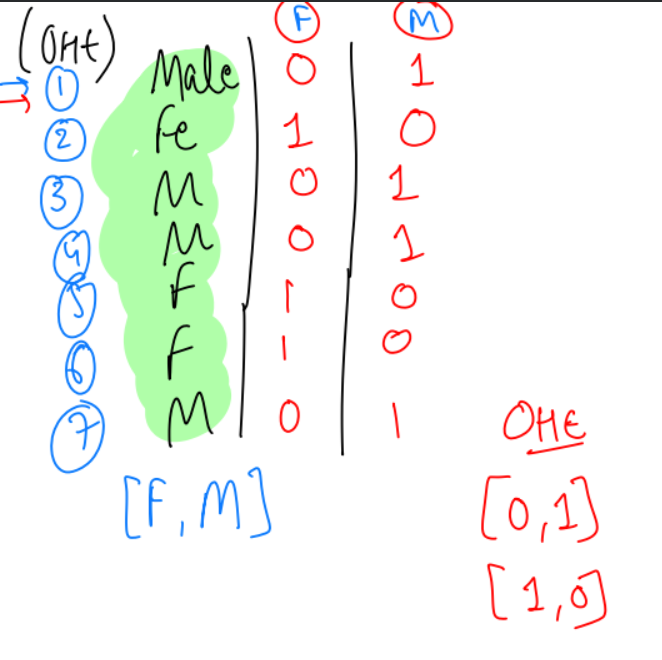

#### <font color='lightgreen'>Label Encoding</font>  

- In this dataset, we'll assign "Male" as 0 and "Female" as 1. Label encoding is suitable when there are only two categories in the dataset, like in this case, as it simplifies the representation without any issues.





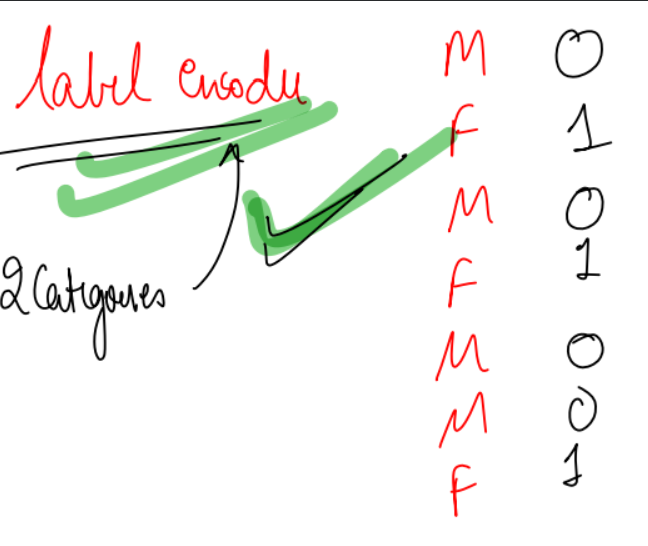

Now I'm giving you one situation and think about it what is the problem in the situation?  

- I'm representing different categories here basically more than 2 categories.  

- Suppose I have 5 different categories A, B, C, D, E and if we apply label encoding on it then  

  Cat A -> 0  
  Dog B -> 1  
  Elephant c -> 2  
  Turtle D -> 3  
  Rat E -> 4  

<font color='violet'>What is the problem here?</font>  

- In the given situation with five categories A, B, C, D, and E, applying label encoding introduces an unintended order to the categories, implying an inherent hierarchy where none exists.
  - $Cat < Dog < Elephant < Turtle < Rat$
- This can lead to bias in the model, as it may assign greater importance to categories with higher numerical labels.

To avoid this issue, especially when dealing with more than two categories, it's advisable to use target encoding instead of label encoding.

Target encoding assigns numerical values based on the target variable, ensuring that no implicit order is introduced.

Another option is one-hot encoding (OHE), but target encoding is preferred over OHE as it avoids creating sparse data with numerous zeros and only a single one.
  - This means there are so many 0s and only a single 1.


In [139]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
# We have to create the instance of the class
updata["Loan_Status"]=label_encoder.fit_transform(updata["Loan_Status"])
updata["Gender"]=label_encoder.fit_transform(updata["Gender"])
updata["Gender"].value_counts()

Gender
1    502
0    112
Name: count, dtype: int64

But what if we have more than 2 categories?

In [140]:
updata["Property_Area"].value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

Now, here you can see we have **more than 2 categories** and we can't represent them with labels 0, 1 and 2 it'll create an order within the categories  

Here we are going to use **Target Encoding**

In [141]:
%pip install --upgrade category_encoders

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [142]:
from category_encoders import TargetEncoder
pd.crosstab(updata["Property_Area"],updata["Loan_Status"],normalize="index")
te=TargetEncoder()
updata["Property_Area"]=te.fit_transform(updata["Property_Area"],updata["Loan_Status"])
# the first parameter passed on is the column on which encoding should happen and second column is the target column
updata["Property_Area"].value_counts()


Property_Area
0.768240    233
0.658416    202
0.614525    179
Name: count, dtype: int64

<font color='violet'>Here can anyone tell what 0.63 represents?</font>

- Is it representing  $P(LS = 1 \mid PA = "Rural")$ or $P(PA = "Rural" \mid LS = 1)$
- It represents the probability that the loan status will be 1 given that the property area is "rural."

Now, can I use our Target Values (1) as targets?

- When converting categorical data into numerical data using Target Encoders, it essentially represents these categories in terms of their **probabilities**.

Do you notice how the categorical values were replaced by numerical values, which are essentially the same as their probabilities?

The values are consistent with the crosstab:
- 0.79 for "Semiurban"
- 0.67 for "Urban"
- 0.63 for "Rural"

However, one issue is that there's an implicit order, but the difference between the values is not significant.

In [143]:
arr=[0,1,2,3,4,5,10]
q1=np.percentile(arr,25)
q3=np.percentile(arr,75)
Iqr=q3-q1
lower_limit=q1-1.5*Iqr
upper_limit=q3+1.5*Iqr
display(lower_limit,upper_limit)

np.float64(-3.0)

np.float64(9.0)

In [144]:
# data=[38,36,31,30,20,28,25,26,19,21,19,21,20,21,21,20,21,24,32,35,38,38]
# mean_value=np.mean(data)
# median_value=np.median(data)
# if(mean_value>median_value):
#     print("Right Skewed")
# else:
#     print("Left Skewed")
# sns.histplot(data)

# 📊 Skewness Cheat Sheet

## 🎯 Identify Skewness Using Histogram

### Positive (Right) Skew

```text
██████████
███████
████
██
█
      →
```

✅ Tail extends to the **Right**

```text
Positive Skew
=
Right Skew
```

---

### Negative (Left) Skew

```text
      █
    ███
  █████
███████
██████████
```

✅ Tail extends to the **Left**

```text
Negative Skew
=
Left Skew
```

---

### Symmetric Distribution

```text
    █
  ████
████████
  ████
    █
```

```text
Mean ≈ Median ≈ Mode
```

---

# 🧮 Numerical Method

## Positive Skew

```text
Mean > Median
```

```text
Right Tail →
```

---

## Negative Skew

```text
Mean < Median
```

```text
← Left Tail
```

---

## Symmetric

```text
Mean ≈ Median
```

---

# 🧠 Memory Trick

```text
Tail Direction Determines Skewness
```

```text
Right Tail  → Positive Skew ➡️

Left Tail   → Negative Skew ⬅️
```

---

# 🚀 Interview Shortcut

| Condition | Distribution |
|------------|-------------|
| Mean > Median | Positive (Right) Skew |
| Mean < Median | Negative (Left) Skew |
| Mean ≈ Median | Symmetric |

---

# ⭐ Best Practice

```text
Histogram     ✅ Visual Check

Mean/Median   ✅ Numerical Check
```

```text
If both agree,
the answer is almost always correct.
```

# 🎯 Choosing the Right Imputation Strategy


## Step 1: Identify Data Type

### Categorical Data

```text
Gender
Country
Department
Subscription Plan
```

➡️ Usually use:

```python
strategy="most_frequent"
```

---

### Numerical Data

```text
Age
Salary
Marks
CO₂ Emissions
Revenue
```

➡️ Continue to Step 2

---

## Step 2: Check Distribution

### Symmetric Distribution

```text
      █
    ████
  ███████
    ████
      █
```

```text
Mean ≈ Median
```

Use:

```python
strategy="mean"
```

---

### Skewed Distribution

```text
█████████
██████
███
█
      →
```

Use:

```python
strategy="median"
```

Why?

```text
Median is resistant to outliers.
Mean gets pulled by extreme values.
```

---

## Step 3: Check for Outliers

### Example

```text
[20, 22, 25, 30, 500]
```

Mean:

```text
119.4 ❌
```

Median:

```text
25 ✅
```

Use:

```python
strategy="median"
```

---

## Step 4: Consider Missing Percentage

| Missing % | Strategy |
|------------|----------|
| < 5% | Impute |
| 5–20% | Analyze |
| 20–40% | Depends on importance |
| > 50% | Consider dropping |
| > 80% | Usually drop |

---

# 🧠 Quick Interview Rules

### Numerical

```text
Normal Distribution
        ↓
       Mean
```

```text
Skewed Data / Outliers
        ↓
      Median
```

### Categorical

```text
Category Data
      ↓
Most Frequent (Mode)
```

### Too Many Missing Values

```text
High Missing %
+
Low Importance
      ↓
Drop Column
```

---

# 🚀 For Your CO₂ Example

```text
50, 196, 221, ...
...
500, 624
```

Large values:

```text
500
624
```

indicate possible right skew/outliers.

Therefore:

```python
SimpleImputer(strategy="median")
```

✅ Better than Mean

In [145]:
url="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/018/746/original/loan.csv?1666170299"
d=pd.read_csv(url)
d.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [146]:
# graduate unmarried men are in a different income group than both married and unmarried graduate women.
from scipy.stats import ttest_ind
firstcase=d[(d["Education"]=="Graduate") & (d["Married"]=="Yes") & (d["Gender"]=="Male") ]["ApplicantIncome"]
secondcase = d[
    (d["Education"]=="Graduate") &
    (d["Gender"]=="Female")
]["ApplicantIncome"]
ttest_ind(firstcase,secondcase)

TtestResult(statistic=np.float64(1.795439979003593), pvalue=np.float64(0.07341069933964262), df=np.float64(365.0))

We have been given a dataset containing the details of the people applied for loan.

dataset: loan.csv

We wish to create a new feature called 'NewFeature' using a linear combination of the features ApplicantIncome, LoanAmount and Credit_History, with weights 1, 3 and 7000,

i.e., data['NewFeature'] = (data["ApplicantIncome"]) + (3 * data["LoanAmount"]) + (7000 * data["Credit_History"]).

Since 'NewFeature' is a numerical feature, convert it to a categorical feature by checking whether 'NewFeature' is greater than 0.25 times the mean of 'NewFeature'. Call this feature 'Separator'.

Perform an appropriate test on the contingency table formed by the features 'Loan_Status' and 'Separator' and report the p-value. Also, report your interpretation.

Note: Drop all the rows having 'na' values before performing any operation on the data, and assume the significance level to be 5%. Also, round off the p-value to four decimal places.

In [147]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# Step 1: Remove missing values
d = d.dropna()

# Step 2: Create NewFeature
d["NewFeature"] = (
    d["ApplicantIncome"]
    + 3 * d["LoanAmount"]
    + 7000 * d["Credit_History"]
)

# Step 3: Calculate mean
newfeaturemean = d["NewFeature"].mean()

# Step 4: Create Separator
d["Separator"] = np.where(
    d["NewFeature"] > 0.25 * newfeaturemean,
    "Y",
    "N"
)

# Step 5: Create contingency table
ct = pd.crosstab(
    d["Loan_Status"],
    d["Separator"]
)

# Step 6: Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(ct)

print(round(p_value, 4))


0.0001


In the loan.csv dataset, we want to test whether there is a significant association between an applicant’s gender and their credit history among those who were rejected for a loan.

Use an appropriate test to verify this claim (Ensure that you drop all nan rows), and report your interpretation.

Note: Use a significance level of 5%.

In [148]:
rejectedd=d[d["Loan_Status"]=="N"]
rejectedd=rejectedd.dropna()
val=pd.crosstab(rejectedd["Gender"],rejectedd["Credit_History"])
chi2_contingency(val)

Chi2ContingencyResult(statistic=np.float64(0.0024123442480440483), pvalue=np.float64(0.9608271544968046), dof=1, expected_freq=array([[13.62162162, 18.37837838],
       [49.37837838, 66.62162162]]))